In [4]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd


from Autoencoders import ConformalAutoencoder
from helper import load_optimizer_and_scheduler, save_optimizer_and_scheduler
from metrics import evaluate_conformality

from torchvision.datasets import MNIST
from torchvision import transforms


random_state = 42
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [5]:
class Encoder(nn.Module):
    def __init__(self, in_channels, latent_dim):
        super(Encoder, self).__init__()
        #input dim = 1, 32, 32
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, 8, 3, stride=2, padding=1),  # (8, 16, 16)
            nn.ReLU(True),
            nn.Conv2d(8, 16, 3, stride=2, padding=1),  # (16, 8, 8)
            nn.ReLU(True),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),  # (32, 4, 4)
            nn.ReLU(True),
        )

        self.fc = nn.Sequential(
            nn.Linear(32 * 4 * 4, 64),  # Flatten to (64,)
            nn.ReLU(True),
            nn.Linear(64, latent_dim)  # Output latent dimension
        )
    
    def forward(self, x):
        x = self.conv(x)
        x = torch.flatten(x, start_dim=1)
        x = self.fc(x)
        return x

class Decoder(nn.Module):
    def __init__(self, out_channels, latent_dim):
        super(Decoder, self).__init__()
        self.fc = nn.Sequential(
            nn.Linear(latent_dim, 64),  # Input latent dimension
            nn.ReLU(True),
            nn.Linear(64, 32 * 4 * 4),  # Output size to reshape
            nn.ReLU(True),
        )
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),  # (16, 6, 6)
            nn.ReLU(True),
            nn.ConvTranspose2d(16, 8, 3, stride=2, padding=1, output_padding=1),  # (8, 12, 12)
            nn.ReLU(True),
            nn.ConvTranspose2d(8, out_channels, 3, stride=2, padding=1, output_padding=1),  # (out_channels, 28, 28)
            nn.Sigmoid()  # For pixel values between 0 and 1
        )
    
    def forward(self, z):
        z = self.fc(z)
        z = torch.unflatten(z, 1, (32, 4, 4))  # Reshape to (32, 4, 4)
        z = self.deconv(z)
        return z

In [6]:
mnist = MNIST(root='data', train=True, download=True, transform=None)
data, labels = mnist.data, mnist.targets
data = data[labels == 3][:3000]
labels = labels[labels == 3]
data = torch.tensor(data, dtype=torch.float32).to(device)
data = transforms.Resize((32, 32))(data)  # Resize to 32x32
data = data / 255.0  # Normalize the images to [0, 1]
data = data.view(data.size(0), 1, 32, 32)  # Add channel dimension
mnist_val = MNIST(root='data', train=False, download=True, transform=None)
val_data, val_labels = mnist_val.data, mnist_val.targets
val_data = val_data[val_labels == 3][:1000]
val_labels = val_labels[val_labels == 3]
val_data = torch.tensor(val_data, dtype=torch.float32).to(device)
val_data = transforms.Resize((32, 32))(val_data)  # Resize to 32x32
val_data = val_data / 255.0  # Normalize the images to [0, 1]
val_data = val_data.view(val_data.size(0), 1, 32, 32)  # Add channel dimension

/tmp/ipykernel_7261/315428273.py:5: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  data = torch.tensor(data, dtype=torch.float32).to(device)
/tmp/ipykernel_7261/315428273.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_data = torch.tensor(val_data, dtype=torch.float32).to(device)


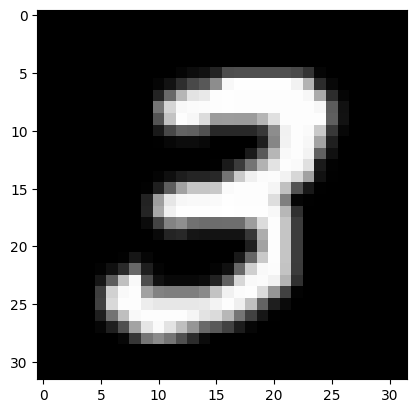

In [7]:
plt.imshow(data[0].view(32, 32).cpu().numpy(), cmap='gray')
plt.show()

In [8]:
# define model parameters
latent_dim = 32
input_dim = data.shape[1]
output_dim = data.shape[1]
batch_size = 256

in_channels = 1  # For grayscale images


train_dataloader = torch.utils.data.DataLoader(data, batch_size=batch_size, shuffle=True)
val_dataloader = torch.utils.data.DataLoader(val_data, batch_size=batch_size, shuffle=False)

dir_path = "models/conformal_autoencoder_trace_comp_mnist"

In [9]:
lambda_isos = np.logspace(-4, 3, 9)
lambda_isos = np.concat([np.zeros(1), lambda_isos])

In [17]:
import os

def modelpath(dir_path, lambda_iso, index):
    os.makedirs(dir_path, exist_ok=True)
    return f"{dir_path}/lambda_{lambda_iso:.3f}_model_{index+1}.pth"

In [11]:
from metrics import conformality_trace_loss

In [16]:
num_epochs = 1000
# train same model multiple times to average results
num_models = 3

recon_errors = []
regularization_errors = []


for i, lambda_iso in enumerate(lambda_isos):
    recon_error = 0
    regularization = 0
    for j in range(num_models):
        print(f"Training model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f}")

        encoder = Encoder(in_channels=in_channels, latent_dim=latent_dim).to(device)
        decoder = Decoder(latent_dim=latent_dim, out_channels=in_channels).to(device)
        model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
        model.conformality_loss = conformality_trace_loss

        optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.8)

        # Train the model
        model.train_model(train_dataloader, val_dataloader, batch_size=batch_size, epochs=num_epochs,
                          optimizer=optimizer, scheduler=scheduler, verbose=True)

        # Save the model and optimizer state
        model_path = modelpath(dir_path, lambda_iso, j)
        torch.save(model.state_dict(), model_path)
        print(f"Model {j+1}/{num_models} with lambda_iso={lambda_iso:.3f} trained and saved.")

        # evaluation
        model.eval()
        encoded_data = model.encode(val_data)
        reconstruction = model.decode(encoded_data)
        
        recon_error += nn.MSELoss()(reconstruction, val_data).item()

        regularization += model.conformality_loss(model.decoder, encoded_data).item()
    
    recon_errors.append(recon_error/ num_models)
    regularization_errors.append(regularization/num_models)
    

Training model 1/3 with lambda_iso=0.000
Epoch [100/1000], Loss: 0.01054364, Reconstruction Loss: 0.01054364, Conformal Loss: 0.00110521
Epoch [100/1000], Validation Loss: 0.01087137, Reconstruction Loss: 0.01087137, Conformal Loss: 0.00114679
Epoch [200/1000], Loss: 0.00610001, Reconstruction Loss: 0.00610001, Conformal Loss: 0.00143000
Epoch [200/1000], Validation Loss: 0.00671991, Reconstruction Loss: 0.00671991, Conformal Loss: 0.00143608
Epoch [300/1000], Loss: 0.00502615, Reconstruction Loss: 0.00502615, Conformal Loss: 0.00152064
Epoch [300/1000], Validation Loss: 0.00583097, Reconstruction Loss: 0.00583097, Conformal Loss: 0.00154988
Epoch [400/1000], Loss: 0.00448021, Reconstruction Loss: 0.00448021, Conformal Loss: 0.00153139
Epoch [400/1000], Validation Loss: 0.00535552, Reconstruction Loss: 0.00535552, Conformal Loss: 0.00152703
Epoch [500/1000], Loss: 0.00410415, Reconstruction Loss: 0.00410415, Conformal Loss: 0.00160551
Epoch [500/1000], Validation Loss: 0.00504374, Reco

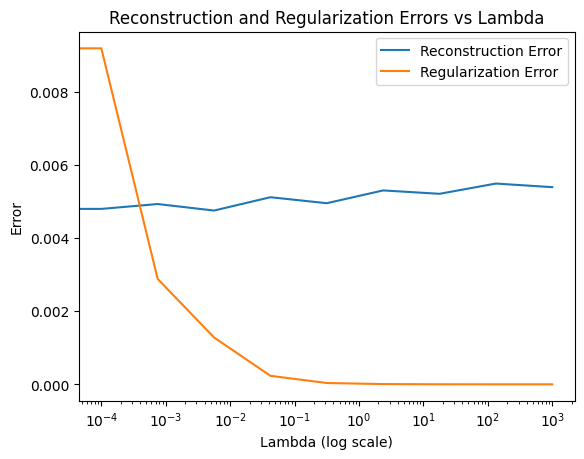

In [19]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0.005, 0.01)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

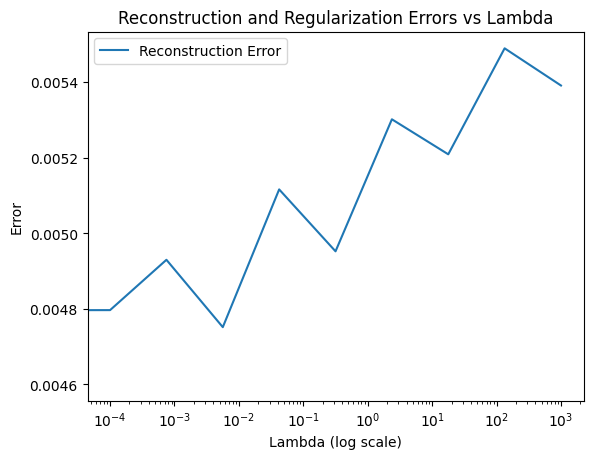

In [22]:
plt.plot(lambda_isos, recon_errors, label='Reconstruction Error')
# plt.plot(lambda_isos, regularization_errors, label='Regularization Error')
# plt.ylim(0.0, 0.00002)
plt.xscale('log')
plt.xlabel('Lambda (log scale)')
plt.ylabel('Error')
plt.title('Reconstruction and Regularization Errors vs Lambda')
plt.legend()
plt.show()

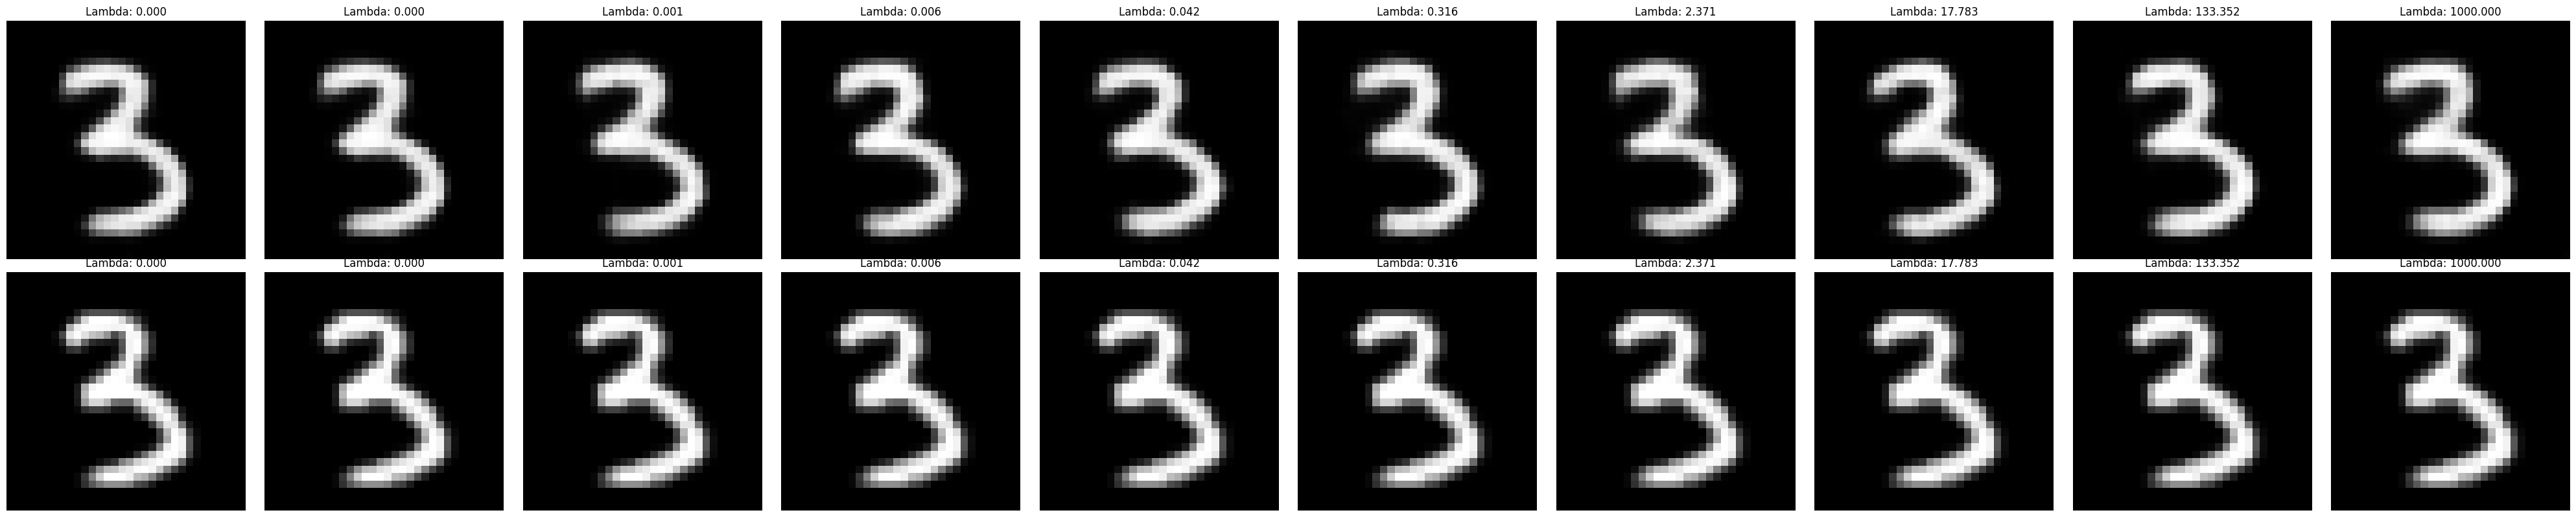

In [23]:
# plot samples and latent space at different lambdas
fig, axs = plt.subplots(2, len(lambda_isos), figsize=(40, 8))
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    # model.eval()
    # with torch.no_grad():
    encoded_data = model.encode(val_data[:10])
    reconstruction = model.decode(encoded_data)

    axs[0, i].imshow(reconstruction[2].view(32, 32).cpu().detach().numpy(), cmap='gray')
    axs[0, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[0, i].axis('off')

    axs[1, i].imshow(val_data[2].view(32, 32).cpu().detach().numpy(), cmap='gray')
    axs[1, i].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[1, i].axis('off')
plt.tight_layout()

In [13]:
import pandas as pd
from metrics import evaluate_conformality

In [15]:
statses = []
encoder = Encoder(in_channels=in_channels, latent_dim=latent_dim).to(device)
decoder = Decoder(latent_dim=latent_dim, out_channels=in_channels).to(device)
for i, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    # with torch.no_grad():
    #     encoded_data = model.encode(val_data)
    #     reconstruction = model.decode(encoded_data)

    statses.append(evaluate_conformality(model, val_data[:100]))

df = pd.DataFrame(statses, index=lambda_isos)
# styled_df = df.style.highlight_min(color='green').highlight_max(color='coral')

torch.cuda.DoubleTensor
tensor([0.0552, 0.0400, 0.0347, 0.0370, 0.0602, 0.0311, 0.0444, 0.0356, 0.0417,
        0.0464, 0.0467, 0.0293, 0.0355, 0.0302, 0.0408, 0.0270, 0.0752, 0.0274,
        0.0312, 0.0410, 0.0336, 0.0340, 0.0407, 0.0446, 0.0274, 0.0380, 0.0445,
        0.0354, 0.0372, 0.0371, 0.0433, 0.0274, 0.0388, 0.0324, 0.0529, 0.0457,
        0.0479, 0.0493, 0.0410, 0.0513, 0.0486, 0.0465, 0.0428, 0.0362, 0.0572,
        0.0477, 0.0398, 0.0433, 0.0312, 0.0423, 0.0454, 0.0426, 0.0346, 0.0362,
        0.0478, 0.0407, 0.0395, 0.0424, 0.0405, 0.0477, 0.0478, 0.0435, 0.0278,
        0.0347, 0.0485, 0.0528, 0.0437, 0.0271, 0.0489, 0.0344, 0.0450, 0.0337,
        0.0300, 0.0378, 0.0352, 0.0454, 0.0427, 0.0362, 0.0479, 0.0501, 0.0280,
        0.0499, 0.0475, 0.0369, 0.0383, 0.0391, 0.0420, 0.0439, 0.0513, 0.0386,
        0.0355, 0.0306, 0.0435, 0.0478, 0.0679, 0.0461, 0.0532, 0.0395, 0.0451,
        0.0410], device='cuda:0', dtype=torch.float64)
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1

In [16]:
styled_df = df.style \
    .background_gradient(subset=[
            'reconstruction_error',
            'diagonal_gini',
            'lambda_std',
            'lambda_std_normed',
            'off_diag_mean',
            'off_diag_norm',
            'off_diag_mean_normed',
            'off_diag_norm_normed',
            'jTj_minus_lambdaI_mean',
            'jTj_minus_lambdaI_norm',
            'jTj_minus_lambdaI_mean_normed',
            'jTj_minus_lambdaI_norm_normed',
            'determinant_vs_estimate_std',
            ], cmap='Reds') \
    .background_gradient(subset=[
        'determinant_vs_estimate_mean'
    ], cmap='Greens')\
    .background_gradient(subset=[
        'lambda_mean',
        'latent_std',
        'latent_std_max',
        'latent_std_min',
        'latent_norm',
    ], cmap='Blues')

styled_df

,reconstruction_error,diagonal_gini,lambda_mean,lambda_std,lambda_std_normed,off_diag_mean,off_diag_norm,off_diag_mean_normed,off_diag_norm_normed,jTj_minus_lambdaI_mean,jTj_minus_lambdaI_norm,jTj_minus_lambdaI_mean_normed,jTj_minus_lambdaI_norm_normed,determinant_vs_estimate_mean,determinant_vs_estimate_std,log_determinant_vs_estimate_mean,log_determinant_vs_estimate_std,latent_std,latent_std_max,latent_std_min,latent_norm
0.000000,0.004779,0.212784,0.041447,0.008534,0.205896,0.007061,0.292368,0.170738,7.068517,0.007455,0.305340,0.180245,7.380230,0.000000,0.000000,-32.514879,2.505322,7.563470,10.969154,3.638018,1078.212646
0.000100,0.004779,0.212784,0.041447,0.008534,0.205896,0.007061,0.292368,0.170738,7.068517,0.007455,0.305340,0.180245,7.380230,0.000000,0.000000,-32.514879,2.505322,7.563470,10.969154,3.638018,1078.212646
0.000750,0.005793,0.217588,0.018926,0.004164,0.219995,0.003495,0.145959,0.185011,7.730643,0.003674,0.151547,0.194490,8.027546,0.000000,0.000000,-34.803188,2.258857,11.692535,18.919291,6.900014,1671.438843
0.005623,0.004907,0.195370,0.015406,0.002769,0.179707,0.002541,0.104959,0.165662,6.840664,0.002669,0.109011,0.174075,7.107506,0.000000,0.000000,-31.439867,2.569613,10.913769,18.423813,6.269447,1650.520020
0.042170,0.005072,0.215230,0.005162,0.000609,0.117914,0.000847,0.035115,0.163834,6.792003,0.000895,0.036883,0.173147,7.136740,0.000000,0.000000,-26.725963,2.299270,21.798939,35.516548,13.471677,2728.424805
0.316228,0.005376,0.185394,0.002421,0.000469,0.193675,0.000399,0.016477,0.165129,6.812074,0.000419,0.017058,0.173216,7.052800,0.000000,0.000000,-28.194582,2.164984,30.110476,45.590530,18.561089,3908.361572
2.371374,0.005688,0.184167,0.001079,0.000180,0.167259,0.000179,0.007435,0.165655,6.882968,0.000187,0.007705,0.173662,7.131845,0.000000,0.000000,-26.533396,2.446825,44.159733,63.160206,28.619638,7630.100098
17.782794,0.004481,0.169182,0.000398,0.000083,0.209314,0.000060,0.002516,0.151318,6.307105,0.000063,0.002608,0.158730,6.534800,0.000000,0.000000,-20.511807,2.470875,80.768738,129.577881,38.454433,9093.632812
133.352143,0.004974,0.170243,0.000153,0.000027,0.179071,0.000024,0.000993,0.154235,6.411222,0.000025,0.001028,0.161697,6.636137,0.000000,0.000000,-20.075520,2.174665,145.605865,219.600998,97.532639,16161.267578
1000.000000,0.005705,0.157381,0.000064,0.000010,0.154397,0.000011,0.000436,0.164483,6.792321,0.000011,0.000447,0.171371,6.972703,0.000000,0.000000,-21.263521,2.025403,284.437073,422.255341,175.128265,29789.207031


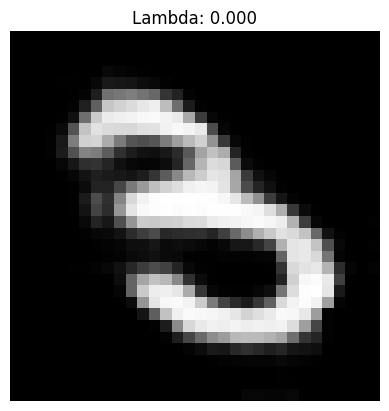

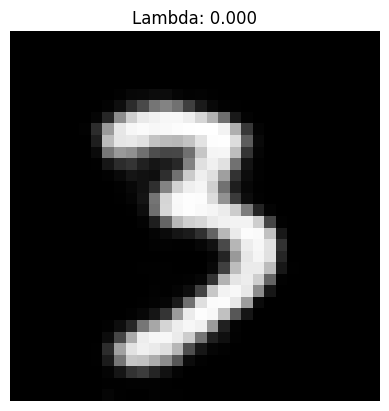

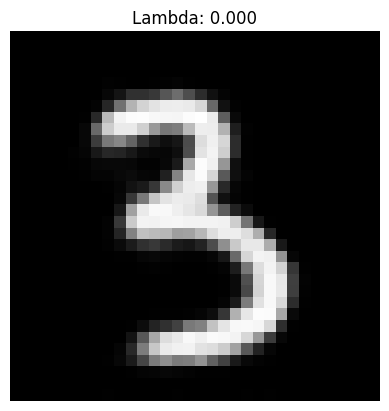

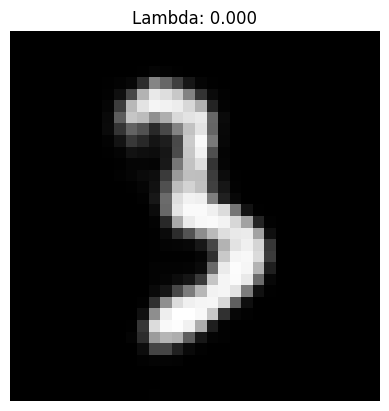

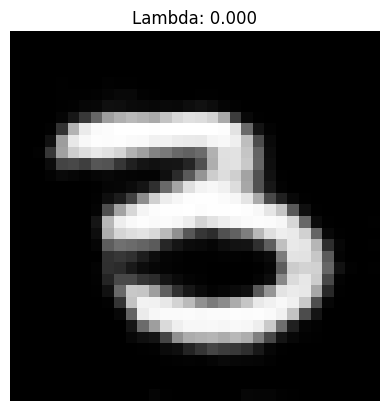

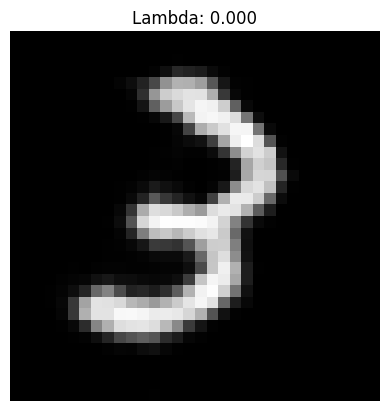

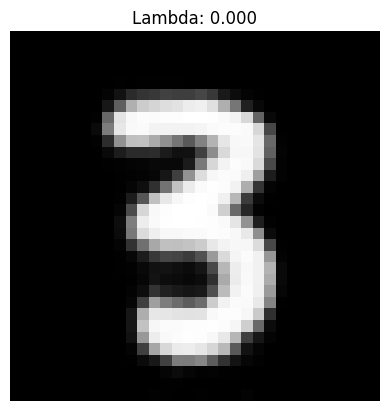

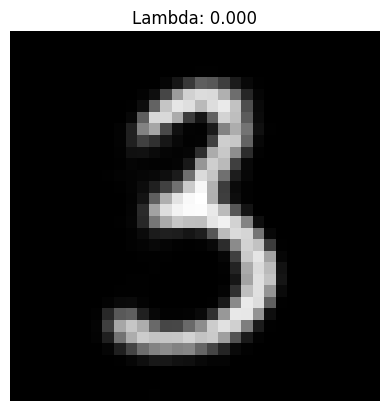

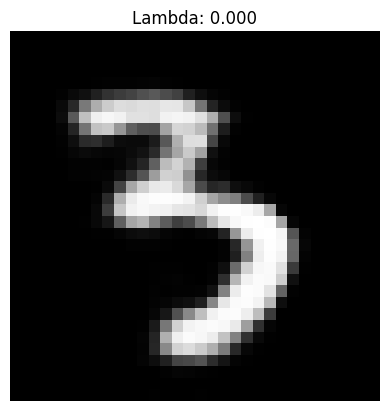

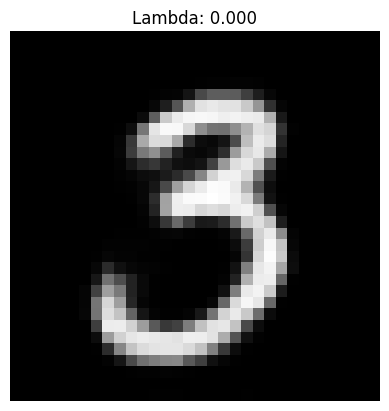

In [18]:
for i in range(10):
    model_path = modelpath(dir_path, 0, 1)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=0).to(device)
    model.load_state_dict(torch.load(model_path))
    
    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[i:i+1])
        reconstruction = model.decode(encoded_data)

    plt.imshow(reconstruction[0].view(32, 32).cpu().detach().numpy(), cmap='gray')
    plt.title(f'Lambda: 0.000')
    plt.axis('off')
    plt.show()

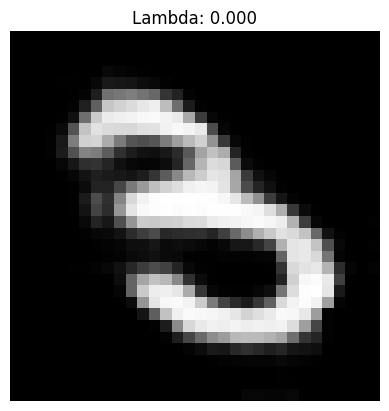

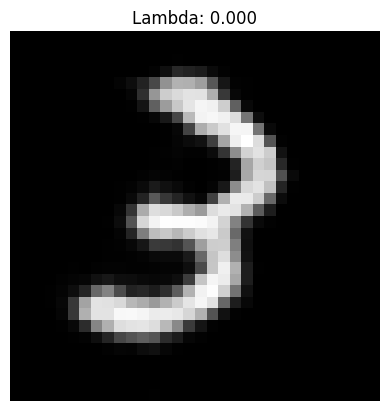

In [21]:
model_path = modelpath(dir_path, 0, 1)
model = ConformalAutoencoder(encoder, decoder, lambda_conf=0).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:10])
    reconstruction = model.decode(encoded_data)

plt.imshow(reconstruction[0].view(32, 32).cpu().detach().numpy(), cmap='gray')
plt.title(f'Lambda: 0.000')
plt.axis('off')
plt.show()
plt.imshow(reconstruction[5].view(32, 32).cpu().detach().numpy(), cmap='gray')
plt.title(f'Lambda: 0.000')
plt.axis('off')
plt.show()

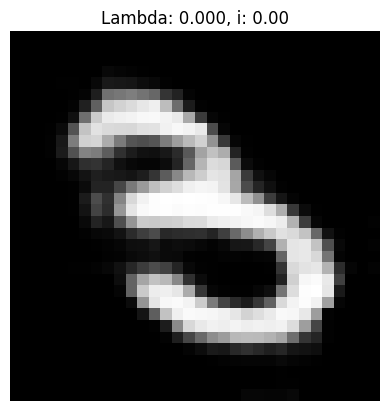

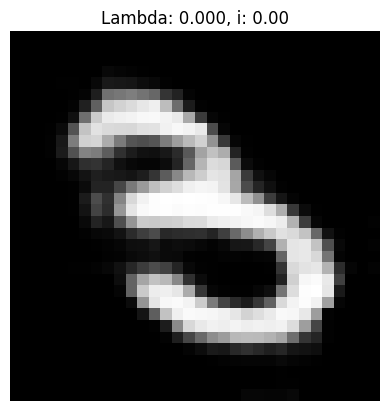

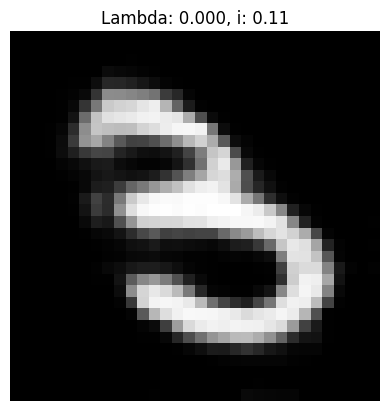

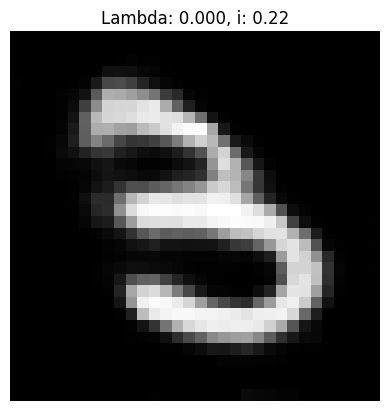

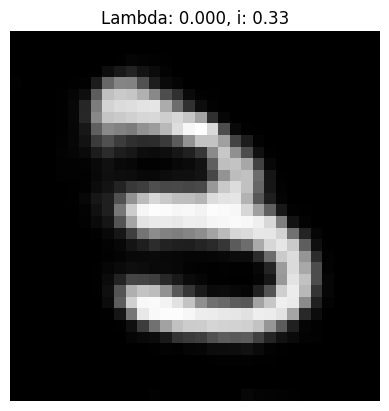

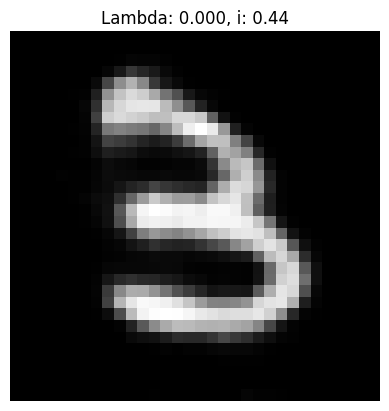

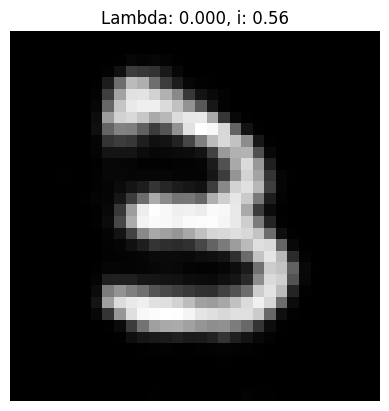

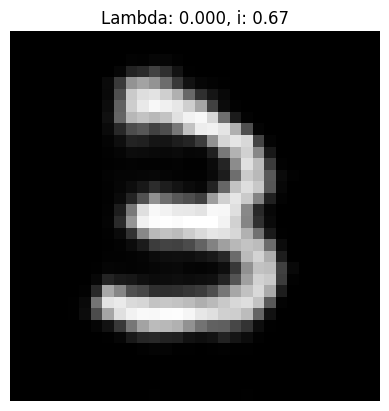

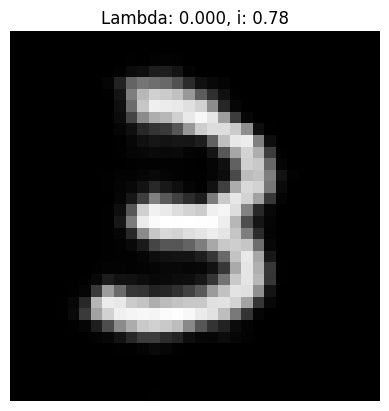

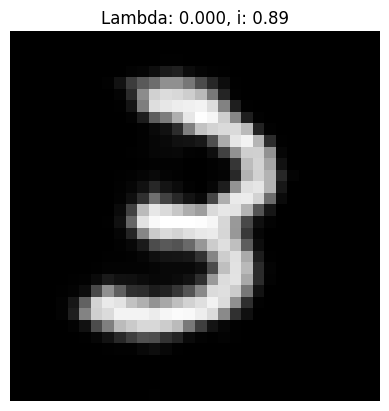

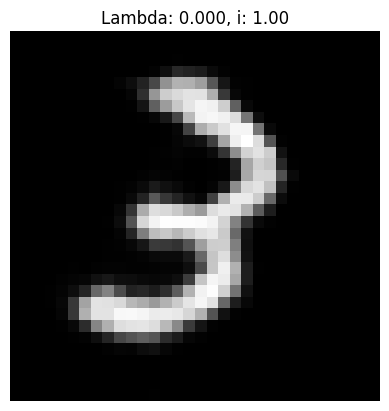

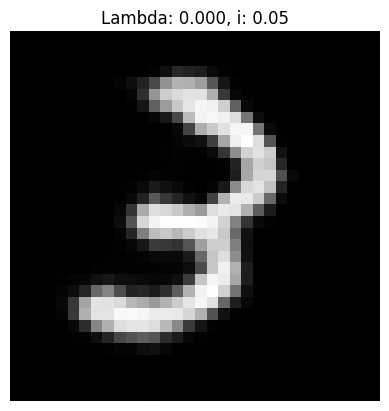

In [25]:
model_path = modelpath(dir_path, 0, 1)
model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data1 = model.encode(val_data[0][None,:])
    reconstruction1 = model.decode(encoded_data)
    encoded_data2 = model.encode(val_data[5][None,:])
    reconstruction2 = model.decode(encoded_data2)

plt.imshow(reconstruction1[0].view(32, 32).cpu().detach().numpy(), cmap='gray')
plt.title(f'Lambda: 0.000, i: 0.00')
plt.axis('off')
plt.show()

a = torch.linspace(0,1,10)
diff = encoded_data2 - encoded_data1
for i in a:
    reco = model.decode(encoded_data1 + i * diff)
    plt.imshow(reco[0].view(32, 32).cpu().detach().numpy(), cmap='gray')
    plt.title(f'Lambda: 0.000, i: {i:.2f}')
    plt.axis('off')
    plt.show()


plt.imshow(reconstruction2[0].view(32, 32).cpu().detach().numpy(), cmap='gray')
plt.title(f'Lambda: 0.000, i: 0.05')
plt.axis('off')
plt.show()

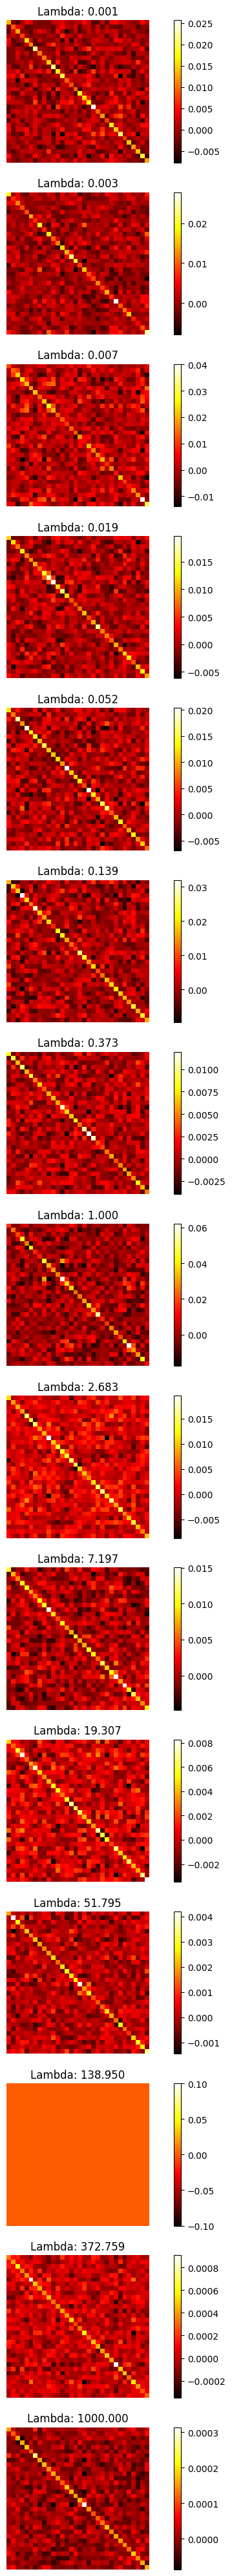

In [ ]:
fig, axs = plt.subplots(len(lambda_isos), 1, figsize=(8, 40))
for j, lambda_iso in enumerate(lambda_isos):
    model_path = modelpath(dir_path, lambda_iso, 2)
    model = ConformalAutoencoder(encoder, decoder, lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[:200])
        reconstruction = model.decode(encoded_data)

    JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension

        J = torch.autograd.functional.jacobian(model.decoder, z)[0,0,:,:,0,:]
        J = J.reshape(-1, 32)  # Reshape to (latent_dim, flattened_output_dim)
        JtJ = J.transpose(0, 1) @ J
        JtJs += JtJ

    JtJs /= encoded_data.shape[0]  # Average over all points

    p = axs[j].imshow(JtJs.cpu().detach().numpy(), cmap='hot')
    axs[j].set_title(f'Lambda: {lambda_iso:.3f}')
    axs[j].axis('off')
    plt.colorbar(p)
plt.tight_layout()

In [ ]:

conformal_autoencoder.eval()
with torch.no_grad():
    encoded_data = conformal_autoencoder.encode(val_data[:1000])
    reconstruction = conformal_autoencoder.decode(encoded_data)

JtJs = torch.zeros((latent_dim, latent_dim)).to(device)
for i, z in enumerate(encoded_data):
    z = z.unsqueeze(0)  # Add batch dimension

    J = torch.autograd.functional.jacobian(conformal_autoencoder.decoder, z)[0,0,:,:,0,:]
    J = J.reshape(-1, 32)  # Reshape to (latent_dim, flattened_output_dim)
    JtJ = J.transpose(0, 1) @ J
    JtJs += JtJ

JtJs /= encoded_data.shape[0]  # Average over all points

plt.imshow(JtJs.cpu().numpy(), cmap='hot')
plt.colorbar()
plt.title('Average J^T J')
plt.axis('off')
plt.show()

In [ ]:
model_path = f"models/conformal_autoencoder_mnist_vec/lambda_{lambda_isos[-1]:.3f}_model_1.pth"
model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_isos[-1]).to(device)
model.load_state_dict(torch.load(model_path))

model.eval()
with torch.no_grad():
    encoded_data = model.encode(val_data[:2])
    reconstruction = model.decode(encoded_data)


    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = model.decoder(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(model.decoder, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J
        print(JtJ.size())
        print(encoded_data.size())

    #     eye = torch.eye(JtJ.size(0), device=device)
    #     off_diag_mask = 1.0 - eye
    #     off_diag_elements = JtJ[off_diag_mask.bool()]
    #     loss_matrix = off_diag_elements ** 2

    #     losses.append(loss_matrix.mean().item())
    
    # return np.mean(losses).item()

torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])
torch.Size([28, 28, 1, 64, 1, 1])
torch.Size([2, 64, 1, 1])


In [49]:
print(JtJ[:,:,0,0,0,0])

tensor([[ 3.0352e-18,  5.2367e-17,  2.9216e-18,  1.0972e-19,  5.9667e-21,
          9.4161e-21,  1.8404e-21,  2.0862e-22,  4.2756e-22,  2.7949e-20,
          9.5245e-20,  7.9838e-20,  2.1337e-22,  1.2245e-24,  4.7852e-26,
          3.2307e-27, -4.6334e-24, -4.1562e-23, -4.6581e-21, -5.7762e-21,
          9.4572e-24,  4.5367e-25,  2.4468e-23,  3.7554e-24,  8.7466e-24,
          2.5008e-23,  3.5209e-21,  2.7895e-17],
        [ 5.2367e-17,  9.0350e-16,  5.0408e-17,  1.8931e-18,  1.0295e-19,
          1.6246e-19,  3.1753e-20,  3.5994e-21,  7.3769e-21,  4.8221e-19,
          1.6433e-18,  1.3775e-18,  3.6813e-21,  2.1127e-23,  8.2561e-25,
          5.5740e-26, -7.9941e-23, -7.1709e-22, -8.0368e-20, -9.9658e-20,
          1.6317e-22,  7.8273e-24,  4.2215e-22,  6.4794e-23,  1.5091e-22,
          4.3147e-22,  6.0748e-20,  4.8128e-16],
        [ 2.9216e-18,  5.0408e-17,  2.8124e-18,  1.0562e-19,  5.7435e-21,
          9.0639e-21,  1.7716e-21,  2.0082e-22,  4.1157e-22,  2.6903e-20,
          9.16

In [35]:
def diagonality_loss(func, z):
    device = z.device
    losses = []
    for i, z in enumerate(encoded_data):
        z = z.unsqueeze(0)  # Add batch dimension
        y = func(z)  # Decode to get reconstruction
        y = y.squeeze(0)  # Remove batch dimension

        # Compute the Jacobian J of the decoder at point z
        J = torch.autograd.functional.jacobian(func, z)[0,:,0,:]
        JtJ = J.transpose(0, 1) @ J

        eye = torch.eye(JtJ.size(0), device=device)
        off_diag_mask = 1.0 - eye
        off_diag_elements = JtJ[off_diag_mask.bool()]
        loss_matrix = off_diag_elements ** 2

        losses.append(loss_matrix.mean().item())
    
    return np.mean(losses).item()

In [13]:
# measure isometry, scaled isometry, conformity, diagonality, (angle preservation, kl)
from metrics import isometry_loss, scaled_isometry_loss, conformality_loss

for i, lambda_iso in enumerate(lambda_isos):
    print(f"Evaluating model with lambda_iso={lambda_iso:.3f}")
    model_path = f"models/conformal_autoencoder_mnist_vec/lambda_{lambda_iso:.3f}_model_1.pth"
    model = ConformalAutoencoder(Encoder(input_dim, latent_dim), Decoder(latent_dim, output_dim), lambda_conf=lambda_iso).to(device)
    model.load_state_dict(torch.load(model_path))

    model.eval()
    with torch.no_grad():
        encoded_data = model.encode(val_data[:10])
        reconstruction = model.decode(encoded_data)

    isometry = isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    scaled_isometry = scaled_isometry_loss(model.decoder, encoded_data, create_graph=False, augment=False)
    # conformality = conformality_loss(model.decoder, encoded_data)
    diagonality = diagonality_loss(model.decoder, encoded_data)
    print(f"Isometry Loss: {isometry.item()}")
    print(f"Scaled Isometry Loss: {scaled_isometry.item()}")
    # print(f"Conformality Loss: {conformality.item()}")
    print(f"Diagonality Loss: {diagonality}")
    print("-" * 50)

Evaluating model with lambda_iso=0.001


RuntimeError: Error(s) in loading state_dict for ConformalAutoencoder:
	size mismatch for decoder.fc.0.weight: copying a param with shape torch.Size([64, 32]) from checkpoint, the shape in current model is torch.Size([64, 1]).
	size mismatch for decoder.deconv.4.weight: copying a param with shape torch.Size([8, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([8, 32, 3, 3]).
	size mismatch for decoder.deconv.4.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current model is torch.Size([32]).
	size mismatch for model.1.fc.0.weight: copying a param with shape torch.Size([64, 32]) from checkpoint, the shape in current model is torch.Size([64, 1]).
	size mismatch for model.1.deconv.4.weight: copying a param with shape torch.Size([8, 1, 3, 3]) from checkpoint, the shape in current model is torch.Size([8, 32, 3, 3]).
	size mismatch for model.1.deconv.4.bias: copying a param with shape torch.Size([1]) from checkpoint, the shape in current mode